# Hybrid Physics-ML Reactor — Production Pipeline

**How to use this notebook**

| Goal | Cells to run |
|---|---|
| First time / retrain | Run **all cells** top to bottom |
| Predict a new reactor state | Run **Cell 1** (imports) → **Cell 7** (load & predict) |
| Change profit parameters | Edit **Cell 1** constants → re-run **Cell 6** onward |

Trained artefacts are saved to `models/` so you never need to retrain unless your data changes.

In [1]:
# ════════════════════════════════════════════════════════════════════════
# CELL 1 — CONSTANTS & IMPORTS
# Edit this cell to change physical parameters or cost assumptions.
# Everything else reads from these variables — change here, nowhere else.
# ════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import joblib, json, os, warnings
from datetime import datetime, timezone
from scipy.integrate import odeint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Physical constants ────────────────────────────────────────────────
R    = 8.314
Ea1, Ea2, Ea3 = 50_000, 70_000, 60_000   # J/mol
A1, A2, A3    = 5.1e7,  2.0e6,  1.5e7
T_NOMINAL     = 300.0   # K — ideal model temperature
TEMP_AMP      = 25.0    # K — day/night swing
K_DEACT       = 0.05    # catalyst deactivation rate

# ── Simulation grid ───────────────────────────────────────────────────
T_MAX, N_POINTS = 48, 1_000
RANDOM_SEED     = 42

# ── Feature order (must never change after training) ─────────────────
FEATURES = ['time', 'temp', 'temp_sq', 'ideal_B', 'B_lag1', 'B_lag2', 'activity']

# ── Profit function parameters ────────────────────────────────────────
PRICE, OP_COST, CATALYST_COST = 1_000, 20, 50

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_PATH    = 'models/best_model.pkl'
SCALER_PATH   = 'models/scaler.pkl'
METADATA_PATH = 'models/metadata.json'
os.makedirs('models', exist_ok=True)

print('✓ Constants loaded')

✓ Constants loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════
# CELL 2 — PHYSICS (ODE functions)
# These are pure functions — no side effects, easy to unit-test.
# ════════════════════════════════════════════════════════════════════════

def ideal_kinetics(y, t):
    """Ideal reactor: constant T=300K, perfect catalyst."""
    A, B, C, D = y
    k1 = A1 * np.exp(-Ea1 / (R * T_NOMINAL))
    k2 = A2 * np.exp(-Ea2 / (R * T_NOMINAL))
    k3 = A3 * np.exp(-Ea3 / (R * T_NOMINAL))
    return [-(k1+k3)*A,  k1*A - k2*B,  k2*B,  k3*A]


def real_system(y, t):
    """Industrial reactor: sinusoidal temperature + catalyst deactivation."""
    A, B, C, D, activity = y
    T  = T_NOMINAL + TEMP_AMP * np.sin(2 * np.pi * t / 24)
    k1 = A1 * np.exp(-Ea1 / (R * T)) * activity
    k2 = A2 * np.exp(-Ea2 / (R * T)) * activity
    k3 = A3 * np.exp(-Ea3 / (R * T)) * activity
    return [-(k1+k3)*A,  k1*A - k2*B,  k2*B,  k3*A,  -K_DEACT*activity*A]


def simulate(t_grid):
    """Solve both ODEs. Returns (ideal_sol [N,4], real_sol [N,5])."""
    ideal = odeint(ideal_kinetics, [1, 0, 0, 0],    t_grid)
    real  = odeint(real_system,    [1, 0, 0, 0, 1], t_grid)
    return ideal, real


print('✓ Physics functions defined')

✓ Physics functions defined


In [3]:
# ════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA GENERATION & PREPROCESSING
# Runs the simulation, adds sensor noise + missing data, builds features.
# ════════════════════════════════════════════════════════════════════════

np.random.seed(RANDOM_SEED)
t = np.linspace(0, T_MAX, N_POINTS)

ideal_sol, real_sol = simulate(t)

df = pd.DataFrame({
    'time':     t,
    'ideal_B':  ideal_sol[:, 1],
    'real_B':   real_sol[:,  1],
    'temp':     T_NOMINAL + TEMP_AMP * np.sin(2 * np.pi * t / 24),
    'activity': real_sol[:, 4],
})

# Sensor noise + random outages
df['real_B'] += np.random.normal(0, 0.002, len(df))
df.loc[df.sample(frac=0.05, random_state=0).index, 'real_B'] = np.nan

valid_mask = ~df['real_B'].isna()   # rows with real measurements

# Imputation + feature engineering
df['real_B_imputed'] = df['real_B'].interpolate(method='linear').bfill()
df['B_lag1']         = df['real_B_imputed'].shift(1).bfill()
df['B_lag2']         = df['real_B_imputed'].shift(2).bfill()
df['temp_sq']        = df['temp'] ** 2
df['residual']       = df['real_B_imputed'] - df['ideal_B']   # ML target

print(f'✓ Dataset ready  — {len(df)} rows, {valid_mask.sum()} with real measurements')
df[FEATURES + ['residual']].describe().round(4)

✓ Dataset ready  — 1000 rows, 950 with real measurements


,time,temp,temp_sq,ideal_B,B_lag1,B_lag2,activity,residual
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,24.0000,300.0000,90312.1875,0.7906,0.8952,0.8942,0.8131,0.1056
std,13.8772,17.6777,10608.9079,0.2469,0.2096,0.2115,0.0378,0.1101
min,0.0000,275.0000,75625.0170,0.0000,0.0010,0.0010,0.7914,0.0003
25%,12.0000,282.3502,79721.6160,0.6982,0.9482,0.9478,0.7921,0.0208
50%,24.0000,300.0000,90000.0000,0.9063,0.9626,0.9625,0.7975,0.0478
75%,36.0000,317.6498,100901.4186,0.9683,0.9906,0.9906,0.8157,0.1736
max,48.0000,325.0000,105624.9799,0.9868,0.9970,0.9970,1.0000,0.3553


In [4]:
# ════════════════════════════════════════════════════════════════════════
# CELL 4 — TRAIN / TEST SPLIT & SCALING
# Scaler is fit on training data only (no leakage).
# ════════════════════════════════════════════════════════════════════════

X_all   = df[FEATURES].values
y_all   = df['residual'].values

X_valid = X_all[valid_mask]
y_valid = y_all[valid_mask]

split    = int(len(X_valid) * 0.80)
X_train, y_train = X_valid[:split], y_valid[:split]
X_test,  y_test  = X_valid[split:], y_valid[split:]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X_all)        # for full-trajectory hybrid predictions

print(f'✓ Split complete  — train: {X_train_s.shape}  test: {X_test_s.shape}')

✓ Split complete  — train: (760, 7)  test: (190, 7)


In [5]:
# ════════════════════════════════════════════════════════════════════════
# CELL 5 — TRAINING
# Trains all three models. Reduce n_trials to speed up during development.
# ════════════════════════════════════════════════════════════════════════

# ── XGBoost with Optuna tuning ─────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',   100, 600),
        'max_depth':        trial.suggest_int('max_depth',         3,   8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample',       0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.6, 1.0),
        'random_state': 42, 'verbosity': 0,
    }
    maes = []
    for tr, val in TimeSeriesSplit(n_splits=5).split(X_train_s):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train_s[tr], y_train[tr])
        maes.append(mean_absolute_error(y_train[val], m.predict(X_train_s[val])))
    return np.mean(maes)

print('Tuning XGBoost...')
study = optuna.create_study(direction='minimize')
study.optimize(xgb_objective, n_trials=50)
xgb_model = xgb.XGBRegressor(**study.best_params, random_state=42, verbosity=0)
xgb_model.fit(X_train_s, y_train)
print(f'  Best params: {study.best_params}')

# ── LightGBM ───────────────────────────────────────────────────────────
print('Training LightGBM...')
X_train_df = pd.DataFrame(X_train_s, columns=FEATURES)
lgb_model = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                random_state=42, verbose=-1)
lgb_model.fit(X_train_df, y_train)

# ── RandomForest ───────────────────────────────────────────────────────
print('Training RandomForest...')
rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf_model.fit(X_train_s, y_train)

print('\n✓ All models trained')

Tuning XGBoost...
  Best params: {'n_estimators': 516, 'max_depth': 3, 'learning_rate': 0.10995654891175162, 'subsample': 0.6016140661808513, 'colsample_bytree': 0.8692335564187514}
Training LightGBM...
Training RandomForest...

✓ All models trained


In [6]:
# ════════════════════════════════════════════════════════════════════════
# CELL 6 — EVALUATE, SELECT BEST & SAVE
# Picks the winner by active-region R², saves model + scaler + metadata.
# ════════════════════════════════════════════════════════════════════════

# ── Hybrid predictions on full dataset ────────────────────────────────
X_all_df = pd.DataFrame(X_all_s, columns=FEATURES)

df['hybrid_xgb'] = df['ideal_B'] + xgb_model.predict(X_all_s)
df['hybrid_lgb'] = df['ideal_B'] + lgb_model.predict(X_all_df)
df['hybrid_rf']  = df['ideal_B'] + rf_model.predict(X_all_s)

# ── Evaluate on active region (where B actually matters) ───────────────
active      = df['ideal_B'] > 0.01
real_active = df.loc[active, 'real_B_imputed'].values

def score(y_true, y_pred):
    return {
        'mae':  round(mean_absolute_error(y_true, y_pred), 5),
        'rmse': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 5),
        'r2':   round(r2_score(y_true, y_pred), 5),
    }

all_scores = {
    'XGBoost':      score(real_active, df.loc[active, 'hybrid_xgb'].values),
    'LightGBM':     score(real_active, df.loc[active, 'hybrid_lgb'].values),
    'RandomForest': score(real_active, df.loc[active, 'hybrid_rf'].values),
}

print('\n── Model performance (active region: ideal_B > 0.01) ──')
for name, s in all_scores.items():
    marker = '  ← BEST' if s['r2'] == max(v['r2'] for v in all_scores.values()) else ''
    print(f"  {name:<15} MAE={s['mae']}  RMSE={s['rmse']}  R²={s['r2']}{marker}")

# ── Select winner ─────────────────────────────────────────────────────
best_name  = max(all_scores, key=lambda n: all_scores[n]['r2'])
best_model = {'XGBoost': xgb_model, 'LightGBM': lgb_model, 'RandomForest': rf_model}[best_name]
best_col   = {'XGBoost': 'hybrid_xgb', 'LightGBM': 'hybrid_lgb', 'RandomForest': 'hybrid_rf'}[best_name]

# ── Profit optimisation ────────────────────────────────────────────────
def profit(yield_b, t_arr):
    return (yield_b * PRICE) - (t_arr * OP_COST) - CATALYST_COST

df['profit_hybrid'] = profit(df[best_col],     df['time'])
df['profit_ideal']  = profit(df['ideal_B'],    df['time'])

opt_time   = df.loc[df['profit_hybrid'].idxmax(), 'time']
ideal_time = df.loc[df['profit_ideal'].idxmax(),  'time']

print(f'\n── Decision report ───────────────────────────────────')
print(f'  Hybrid stop time : {opt_time:.2f} h')
print(f'  Ideal  stop time : {ideal_time:.2f} h')
print(f'  Improvement      : {abs(opt_time - ideal_time):.2f} h')

# ── Save artefacts ─────────────────────────────────────────────────────
joblib.dump(best_model, MODEL_PATH,  compress=3)
joblib.dump(scaler,     SCALER_PATH, compress=3)

metadata = {
    'model_name':    best_name,
    'trained_at':    datetime.now(timezone.utc).isoformat(),
    'features':      FEATURES,
    'metrics':       all_scores[best_name],
    'all_scores':    all_scores,
    'profit_params': {'price': PRICE, 'op_cost': OP_COST, 'catalyst_cost': CATALYST_COST},
    'decision':      {'hybrid_stop_h': round(opt_time, 2),
                      'ideal_stop_h':  round(ideal_time, 2),
                      'improvement_h': round(abs(opt_time - ideal_time), 2)},
}
with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

# ── Smoke test — reload and verify ────────────────────────────────────
_m = joblib.load(MODEL_PATH)
_s = joblib.load(SCALER_PATH)
_x = _s.transform(X_all[:5])
_inp = pd.DataFrame(_x, columns=FEATURES) if best_name == 'LightGBM' else _x
assert np.allclose(_m.predict(_inp), best_model.predict(_inp), atol=1e-6), \
    'Smoke test FAILED — reloaded model differs!'

print(f'\n✓ Saved  {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1024:.0f} KB)')
print(f'✓ Saved  {SCALER_PATH}')
print(f'✓ Saved  {METADATA_PATH}')
print('✓ Smoke test passed')


── Model performance (active region: ideal_B > 0.01) ──
  XGBoost         MAE=0.00277  RMSE=0.00489  R²=0.99941
  LightGBM        MAE=0.00502  RMSE=0.01006  R²=0.99752
  RandomForest    MAE=0.0028  RMSE=0.00472  R²=0.99945  ← BEST

── Decision report ───────────────────────────────────
  Hybrid stop time : 8.89 h
  Ideal  stop time : 16.00 h
  Improvement      : 7.11 h

✓ Saved  models/best_model.pkl  (2603 KB)
✓ Saved  models/scaler.pkl
✓ Saved  models/metadata.json
✓ Smoke test passed


In [7]:
# ════════════════════════════════════════════════════════════════════════
# CELL 7 — PREDICT  (run this cell anytime, no retraining needed)
#
# Two modes:
#   predict_point()      — single reactor state → hybrid B + correction
#   predict_trajectory() — full 48h run → B profile + optimal stop time
# ════════════════════════════════════════════════════════════════════════

import joblib, json, numpy as np, pandas as pd

# ── Load from disk (works even in a fresh kernel) ─────────────────────
_model  = joblib.load(MODEL_PATH)
_scaler = joblib.load(SCALER_PATH)
with open(METADATA_PATH) as f:
    _meta = json.load(f)

def _scale_and_predict(X_raw):
    """Scale features and call the right model input type."""
    X_s = _scaler.transform(np.atleast_2d(X_raw))
    if _meta['model_name'] == 'LightGBM':
        return _model.predict(pd.DataFrame(X_s, columns=_meta['features']))
    return _model.predict(X_s)


def predict_point(time_h, temp_K, ideal_B, B_lag1, B_lag2, activity):
    """
    Predict hybrid B for a single reactor state.

    Parameters
    ----------
    time_h   : current elapsed time (hours)
    temp_K   : current reactor temperature (Kelvin)
    ideal_B  : ideal ODE prediction for B at this state
    B_lag1   : B measurement from 1 time step ago
    B_lag2   : B measurement from 2 time steps ago
    activity : current catalyst activity (0–1)

    Returns dict with hybrid_B, ideal_B, ml_correction
    """
    features = [time_h, temp_K, temp_K**2, ideal_B, B_lag1, B_lag2, activity]
    correction = float(_scale_and_predict([features])[0])
    return {
        'hybrid_B':      round(ideal_B + correction, 6),
        'ideal_B':       round(ideal_B, 6),
        'ml_correction': round(correction, 6),
        'model_used':    _meta['model_name'],
    }


def predict_trajectory(n_points=500, t_max_h=48.0):
    """
    Predict the full B trajectory and find the profit-optimal stop time.
    Uses the ideal ODE + real activity from the simulation.

    Returns a DataFrame with columns:
        time, ideal_B, hybrid_B, profit, is_optimal_stop
    """
    from scipy.integrate import odeint

    t_grid   = np.linspace(0, t_max_h, n_points)
    ideal    = odeint(ideal_kinetics, [1, 0, 0, 0],    t_grid)
    real     = odeint(real_system,    [1, 0, 0, 0, 1], t_grid)

    ideal_B  = ideal[:, 1]
    activity = real[:, 4]
    temp     = T_NOMINAL + TEMP_AMP * np.sin(2 * np.pi * t_grid / 24)
    B_lag1   = np.concatenate([[ideal_B[0]], ideal_B[:-1]])
    B_lag2   = np.concatenate([[ideal_B[0], ideal_B[0]], ideal_B[:-2]])

    X_raw = np.column_stack([t_grid, temp, temp**2, ideal_B, B_lag1, B_lag2, activity])
    hybrid_B = ideal_B + _scale_and_predict(X_raw)

    profits  = (hybrid_B * PRICE) - (t_grid * OP_COST) - CATALYST_COST
    best_idx = int(np.argmax(profits))

    result = pd.DataFrame({
        'time':             t_grid,
        'ideal_B':          ideal_B,
        'hybrid_B':         hybrid_B,
        'profit':           profits,
        'is_optimal_stop':  [i == best_idx for i in range(n_points)],
    })

    stop_time = t_grid[best_idx]
    print(f'✓ Trajectory computed  ({n_points} points, horizon={t_max_h}h)')
    print(f'  Optimal stop time : {stop_time:.2f} h')
    print(f'  Max profit        : {profits[best_idx]:,.1f}')
    print(f'  hybrid_B at stop  : {hybrid_B[best_idx]:.4f}')
    return result


print(f'✓ Predictor ready  ({_meta["model_name"]} — R²={_meta["metrics"]["r2"]})')
print()
print('  Usage:')
print('    predict_point(time_h=10, temp_K=302, ideal_B=0.50, B_lag1=0.49, B_lag2=0.48, activity=0.85)')
print('    predict_trajectory()')

✓ Predictor ready  (RandomForest — R²=0.99945)

  Usage:
    predict_point(time_h=10, temp_K=302, ideal_B=0.50, B_lag1=0.49, B_lag2=0.48, activity=0.85)
    predict_trajectory()


In [8]:
# ════════════════════════════════════════════════════════════════════════
# CELL 8 — EXAMPLE PREDICTIONS  (edit inputs here)
# ════════════════════════════════════════════════════════════════════════

# ── Point prediction ──────────────────────────────────────────────────
# Change these values to match your actual reactor readings:
result = predict_point(
    time_h   = 10.0,    # hours elapsed
    temp_K   = 302.0,   # current temperature (K)
    ideal_B  = 0.50,    # what the ideal ODE says B should be
    B_lag1   = 0.49,    # B one reading ago
    B_lag2   = 0.48,    # B two readings ago
    activity = 0.85,    # catalyst activity (measure or estimate)
)
print('Point prediction:')
for k, v in result.items():
    print(f'  {k:<18} {v}')

print()

# ── Full trajectory + optimal stop ────────────────────────────────────
traj = predict_trajectory(n_points=500, t_max_h=48.0)

print()
print('Trajectory sample (every 50th row):')
traj.iloc[::50][['time','ideal_B','hybrid_B','profit','is_optimal_stop']].round(4)

Point prediction:
  hybrid_B           0.770421
  ideal_B            0.5
  ml_correction      0.270421
  model_used         RandomForest

✓ Trajectory computed  (500 points, horizon=48.0h)
  Optimal stop time : 10.00 h
  Max profit        : 686.6
  hybrid_B at stop  : 0.9366

Trajectory sample (every 50th row):


,time,ideal_B,hybrid_B,profit,is_optimal_stop
0,0.0000,0.0000,0.0016,-48.4461,False
50,4.8096,0.3824,0.6268,480.5774,False
100,9.6192,0.6178,0.9184,675.9856,False
150,14.4289,0.7626,0.9532,614.6305,False
200,19.2385,0.8518,0.9559,521.1590,False
250,24.0481,0.9067,0.9651,434.0948,False
300,28.8577,0.9405,0.9866,359.4122,False
350,33.6673,0.9613,0.9924,269.0925,False
400,38.4770,0.9741,0.9950,175.5082,False
450,43.2866,0.9820,1.0029,87.1894,False


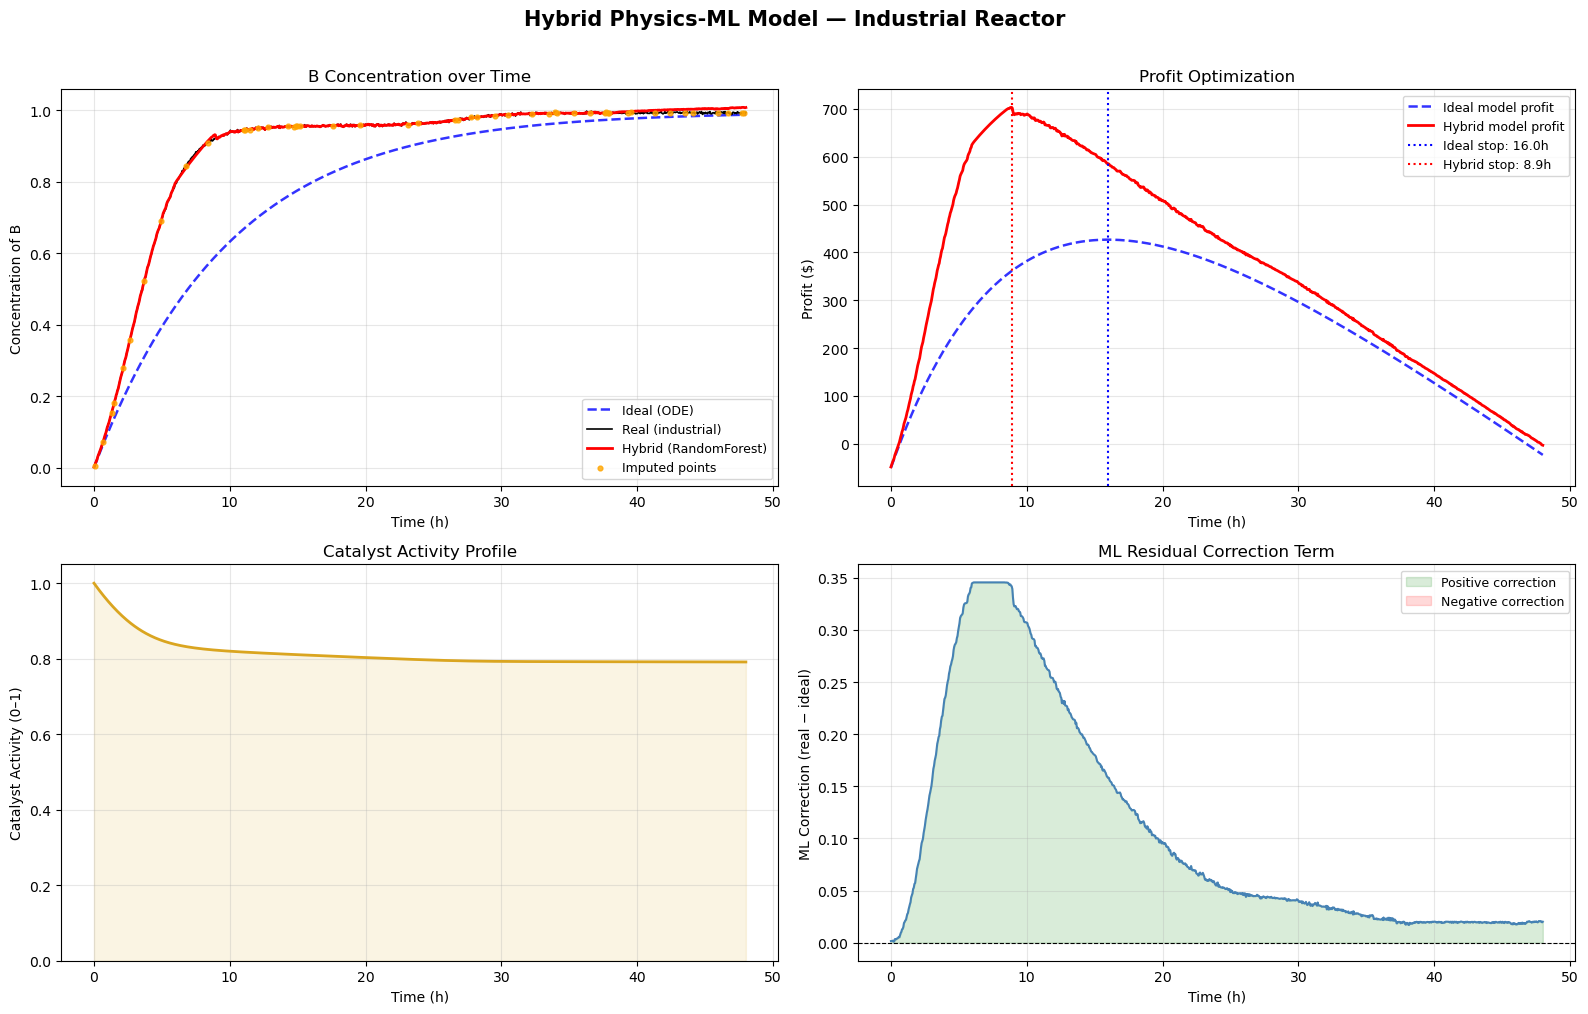

✓ Figure 1 saved: plot1_concentration_and_profit.png


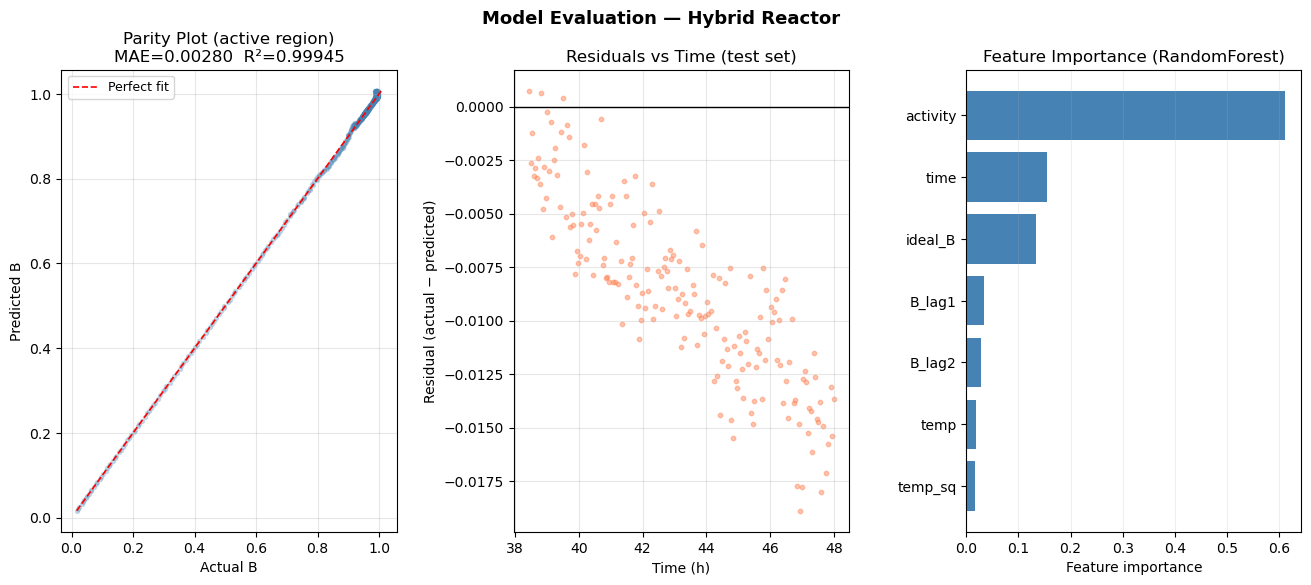

✓ Figure 2 saved: plot2_evaluation.png


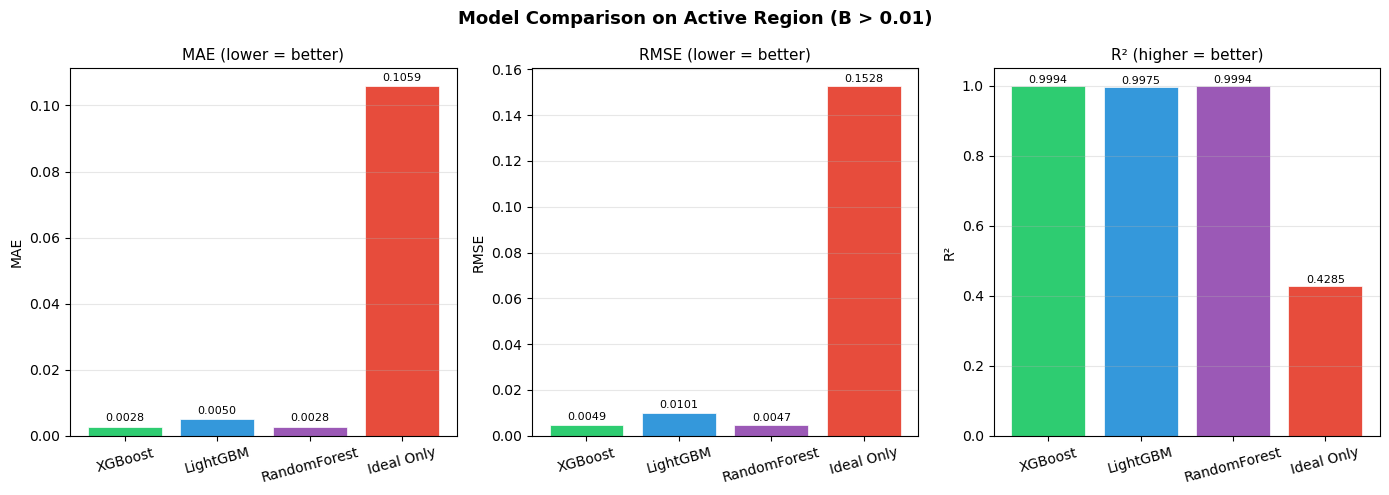

✓ Figure 3 saved: plot3_model_comparison.png


In [16]:
# ════════════════════════════════════════════════════════════════════════
# CELL 9 — FULL VISUALIZATION SUITE
# Produces all 6 plots:
#   1. Concentration profiles (Ideal vs Real vs Hybrid)
#   2. Parity plot (active region)
#   3. Residuals vs time
#   4. SHAP feature importance
#   5. Catalyst activity profile
#   6. ML correction term over time
#   7. Profit optimization curves
# Run Cell 1-6 first (or just Cell 1 + Cell 7 if models are saved).
# ════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import shap
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# ── Re-derive ML correction on full dataset ───────────────────────────
# (safe to re-run; uses df, best_col, scaler, best_model from Cell 6)
active_mask = df['ideal_B'] > 0.01
valid_mask_bool = ~df['real_B'].isna()

correction_full = df[best_col] - df['ideal_B']   # ML correction term

# ── SHAP values (XGBoost only — skip if best model is not XGB) ────────
shap_available = (best_name == 'XGBoost')
if shap_available:
    explainer   = shap.Explainer(best_model, feature_names=FEATURES)
    shap_values = explainer(pd.DataFrame(X_test_s, columns=FEATURES))

# ─────────────────────────────────────────────────────────────────────
# FIGURE 1 — Concentration profiles + Catalyst activity + ML correction
# (matches the 4-panel layout in the Streamlit app)
# ─────────────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(16, 10))
fig1.suptitle('Hybrid Physics-ML Model — Industrial Reactor', fontsize=15, fontweight='bold', y=1.01)

# Panel 1: B concentration
ax = axes[0, 0]
ax.plot(t, df['ideal_B'],    'b--', lw=1.8, label='Ideal (ODE)', alpha=0.8)
ax.plot(t, df['real_B'],     'k-',  lw=1.2, label='Real (industrial)', zorder=4)
ax.plot(t, df[best_col],     'r-',  lw=2.0, label=f'Hybrid ({best_name})', zorder=5)
imputed_idx = np.where(valid_mask_bool == False)[0]
ax.scatter(t[imputed_idx], df.loc[imputed_idx, 'real_B_imputed'],
           color='orange', s=12, zorder=6, label='Imputed points', alpha=0.8)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Concentration of B')
ax.set_title('B Concentration over Time')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 2: Profit curves
ax2 = axes[0, 1]
opt_hybrid_idx = df['profit_hybrid'].idxmax()
opt_ideal_idx  = df['profit_ideal'].idxmax()
ax2.plot(t, df['profit_ideal'],  'b--', lw=1.8, label='Ideal model profit', alpha=0.8)
ax2.plot(t, df['profit_hybrid'], 'r-',  lw=2.0, label='Hybrid model profit')
ax2.axvline(df.loc[opt_ideal_idx,  'time'], color='blue',  ls=':', lw=1.5,
            label=f'Ideal stop: {ideal_time:.1f}h')
ax2.axvline(df.loc[opt_hybrid_idx, 'time'], color='red',   ls=':', lw=1.5,
            label=f'Hybrid stop: {opt_time:.1f}h')
ax2.set_xlabel('Time (h)'); ax2.set_ylabel('Profit ($)')
ax2.set_title('Profit Optimization')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Panel 3: Catalyst activity
ax3 = axes[1, 0]
ax3.plot(t, df['activity'], color='goldenrod', lw=2.0)
ax3.fill_between(t, 0, df['activity'], alpha=0.12, color='goldenrod')
ax3.set_xlabel('Time (h)'); ax3.set_ylabel('Catalyst Activity (0–1)')
ax3.set_title('Catalyst Activity Profile')
ax3.set_ylim(0, 1.05); ax3.grid(alpha=0.3)

# Panel 4: ML correction term
ax4 = axes[1, 1]
ax4.plot(t, correction_full, color='steelblue', lw=1.5)
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.fill_between(t, 0, correction_full,
                 where=correction_full >= 0, alpha=0.15, color='green', label='Positive correction')
ax4.fill_between(t, 0, correction_full,
                 where=correction_full < 0,  alpha=0.15, color='red',   label='Negative correction')
ax4.set_xlabel('Time (h)'); ax4.set_ylabel('ML Correction (real − ideal)')
ax4.set_title('ML Residual Correction Term')
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot1_concentration_and_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 1 saved: plot1_concentration_and_profit.png')

# ─────────────────────────────────────────────────────────────────────
# FIGURE 2 — Model evaluation: Parity plot + Residuals + SHAP
# ─────────────────────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(16, 6))
gs   = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.35)

# Panel 1: Parity plot (active region)
ax_p = fig2.add_subplot(gs[0, 0])
real_act = df.loc[active_mask, 'real_B_imputed'].values
pred_act = df.loc[active_mask, best_col].values
ax_p.scatter(real_act, pred_act, alpha=0.25, s=8, color='steelblue')
lim = [min(real_act.min(), pred_act.min()), max(real_act.max(), pred_act.max())]
ax_p.plot(lim, lim, 'r--', lw=1.2, label='Perfect fit')
ax_p.set_xlabel('Actual B'); ax_p.set_ylabel('Predicted B')
ax_p.set_title(f'Parity Plot (active region)\nMAE={mean_absolute_error(real_act,pred_act):.5f}  R²={r2_score(real_act,pred_act):.5f}')
ax_p.legend(fontsize=9); ax_p.grid(alpha=0.3)

# Panel 2: Residuals vs time (test set)
ax_r = fig2.add_subplot(gs[0, 1])
t_valid_idx  = np.where(valid_mask_bool)[0]
split        = int(len(t_valid_idx) * 0.80)
test_times   = t[t_valid_idx[split:]]
ideal_test   = df['ideal_B'].values[t_valid_idx[split:]]
real_test    = df['real_B_imputed'].values[t_valid_idx[split:]]
hybrid_test  = df[best_col].values[t_valid_idx[split:]]
residuals    = real_test - hybrid_test
ax_r.scatter(test_times, residuals, alpha=0.45, s=10, color='coral')
ax_r.axhline(0, color='black', lw=1)
ax_r.set_xlabel('Time (h)'); ax_r.set_ylabel('Residual (actual − predicted)')
ax_r.set_title('Residuals vs Time (test set)')
ax_r.grid(alpha=0.3)

# Panel 3: SHAP or native feature importance
ax_s = fig2.add_subplot(gs[0, 2])
if shap_available:
    mean_shap = np.abs(shap_values.values).mean(axis=0)
    feat_order = np.argsort(mean_shap)
    ax_s.barh([FEATURES[i] for i in feat_order], mean_shap[feat_order], color='#e05c97')
    ax_s.set_xlabel('mean(|SHAP value|)')
    ax_s.set_title('SHAP Feature Importance (XGBoost)')
else:
    importances = best_model.feature_importances_
    feat_order  = np.argsort(importances)
    ax_s.barh([FEATURES[i] for i in feat_order], importances[feat_order], color='steelblue')
    ax_s.set_xlabel('Feature importance')
    ax_s.set_title(f'Feature Importance ({best_name})')
ax_s.grid(alpha=0.2, axis='x')

plt.suptitle('Model Evaluation — Hybrid Reactor', fontsize=13, fontweight='bold')
plt.savefig('plot2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 2 saved: plot2_evaluation.png')

# ─────────────────────────────────────────────────────────────────────
# FIGURE 3 — Model comparison bar chart
# ─────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(14, 5))
fig3.suptitle('Model Comparison on Active Region (B > 0.01)', fontsize=13, fontweight='bold')

model_names  = list(all_scores.keys()) + ['Ideal Only']
mae_vals     = [all_scores[n]['mae']  for n in all_scores] + [
    round(mean_absolute_error(
        df.loc[active_mask, 'real_B_imputed'].values,
        df.loc[active_mask, 'ideal_B'].values), 5)]
rmse_vals    = [all_scores[n]['rmse'] for n in all_scores] + [
    round(float(np.sqrt(((df.loc[active_mask,'real_B_imputed'].values -
                          df.loc[active_mask,'ideal_B'].values)**2).mean())), 5)]
r2_vals      = [all_scores[n]['r2']   for n in all_scores] + [
    round(r2_score(df.loc[active_mask,'real_B_imputed'].values,
                   df.loc[active_mask,'ideal_B'].values), 5)]

colors = ['#2ecc71','#3498db','#9b59b6','#e74c3c']

for ax_, vals, title, better in zip(axes3,
                                     [mae_vals, rmse_vals, r2_vals],
                                     ['MAE (lower = better)','RMSE (lower = better)','R² (higher = better)'],
                                     ['low','low','high']):
    bars = ax_.bar(model_names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax_.set_title(title, fontsize=11)
    ax_.set_ylabel(title.split()[0])
    ax_.tick_params(axis='x', rotation=15)
    ax_.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax_.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 3 saved: plot3_model_comparison.png')
